In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import Margins, pairwise

data = sm.datasets.spector.load_pandas()
df = data.exog.copy()
df["GRADE"] = data.endog.astype(int)
print(df.describe().round(2))

         GPA   TUCE    PSI  GRADE
count  32.00  32.00  32.00  32.00
mean    3.12  21.94   0.44   0.34
std     0.47   3.90   0.50   0.48
min     2.06  12.00   0.00   0.00
25%     2.81  19.75   0.00   0.00
50%     3.06  22.50   0.00   0.00
75%     3.51  25.00   1.00   1.00
max     4.00  29.00   1.00   1.00


In [2]:
fit = smf.glm(
    "GRADE ~ GPA + TUCE + PSI",
    data=df,
    family=sm.families.Binomial(),
).fit()
print(fit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -13.0213      4.931     -2.641      0.008     -22.686      -3.356
GPA            2.8261      1.263      2.238      0.025       0.351       5.301
TUCE           0.0952      0.142      0.672      0.501      -0.182       0.373
PSI            2.3787      1.065      2.234      0.025       0.292       4.465


In [3]:
scen, w = pairwise("PSI", [1, 0])

m_delta = Margins.linear_scale(fit, vcov="HC1", at="overall")
print("Delta method:")
print(m_delta.contrasts(scenarios=scen, contrasts=w).summary())

Delta method:


            Margins Result (delta, level=0.95)           
       estimate  std err       z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------
PSI=1    0.3575   0.1508  2.3709  0.018    0.0620, 0.6531

n = 32
κ: 0.214
Delta-vs-sim disagreement: 6.110%


In [4]:
m_sim = Margins.linear_scale(
    fit, vcov="HC1", at="overall",
    method="simulation", n_sim=2000, rng_seed=0,
)
print("Krinsky–Robb simulation:")
print(m_sim.contrasts(scenarios=scen, contrasts=w).summary())

Krinsky–Robb simulation:


          Margins Result (simulation, level=0.95)           
       estimate  std err  statistic  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
PSI=1    0.3575   0.1388     0.3575  0.014    0.0719, 0.6153

n = 32
κ: 0.214


In [5]:
print(m_delta.diagnose().summary())

Session diagnostic (32 design points)
  Session: Margins session
  Model: GLMResultsWrapper
  Adapter: StatsmodelsGLMAdapter
  Inference scale: identity
  Variance: HC1
  Confidence level: 0.95
  At: overall
  Method: delta (κ-threshold=0.3)
  n_sim: 4000
  n_boot: 1000 
  Gradient backend: autodiff
  Diagnostics: enabled
  Strict: False
  κ min:    0.042
  κ median: 0.632
  κ max:    1.488
  Verdict:  delta_unreliable
  Delta method is unreliable for this analytical posture. Use method='simulation' or method='bootstrap' for inference, or reconsider the inference scale (phi).


In [6]:
gpas = [2.5, 3.0, 3.5]
k = len(gpas)
scenarios = [
    {"atexog": {"PSI": 1, "GPA": g}, "label": f"PSI=1, GPA={g}"} for g in gpas
] + [
    {"atexog": {"PSI": 0, "GPA": g}, "label": f"PSI=0, GPA={g}"} for g in gpas
]
W = np.zeros((k, 2 * k))
for i in range(k):
    W[i, i] = +1.0
    W[i, k + i] = -1.0
het = m_delta.contrasts(scenarios=scenarios, contrasts=W)
print(het.summary())

/home/hunter/Workspace/pymargins/.venv/lib/python3.12/site-packages/pymargins/margins/_session.py:868: UserWarning: Delta-method curvature κ=0.712 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


             Margins Result (simulation, level=0.95)              
             estimate  std err  statistic  P>|z|  [95% Conf. Int.]
------------------------------------------------------------------
contrast[0]    0.1684   0.1532     0.1684  0.013    0.0123, 0.5676
contrast[1]    0.3989   0.1622     0.3989  0.013    0.0724, 0.6889
contrast[2]    0.5190   0.1656     0.5190  0.013    0.1127, 0.7453

n = 32
WARNING — Fallback triggered: kappa=0.712>threshold=0.3
κ: max=0.712


/home/hunter/Workspace/pymargins/.venv/lib/python3.12/site-packages/pymargins/margins/_session.py:626: UserWarning: Delta-method curvature κ=1.771 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


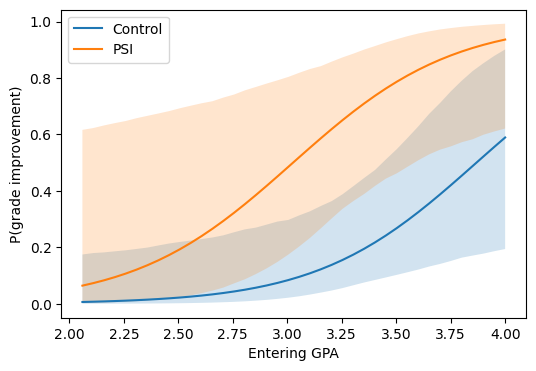

In [7]:
import matplotlib.pyplot as plt

gpa_grid = np.linspace(df["GPA"].min(), df["GPA"].max(), 40)
res = m_delta.predict(atexog={"GPA": gpa_grid, "PSI": [0, 1]})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
for psi, sub in df_plot.groupby("PSI"):
    label = "PSI" if psi == 1 else "Control"
    ax.plot(sub["GPA"], sub["estimate"], label=label)
    ax.fill_between(
        sub["GPA"], sub["ci_lower"], sub["ci_upper"], alpha=0.2
    )
ax.set(xlabel="Entering GPA", ylabel="P(grade improvement)")
ax.legend()